In [1]:
import tensorflow
from tensorflow import keras
from keras.layers import Dense, Conv2D,Flatten,MaxPooling2D
from keras import Sequential
from keras.datasets import mnist

In [7]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Reshape data to add channel dimension for Conv2D layer
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32') / 255

# One-hot encode labels
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [8]:
model = Sequential()

model.add(Conv2D(6 , kernel_size=(5,5),padding='valid' , activation='tanh' , input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(16 , kernel_size=(5,5),padding='valid' , activation='tanh'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(120, activation='tanh'))
model.add(Dense(84, activation='tanh'))
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adam(), metrics=['accuracy'])
model.fit(X_train, y_train, batch_size=128, epochs=10, verbose=1, validation_data=(X_test, y_test))
score = model.evaluate(X_test, y_test, verbose=0)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.9193 - loss: 0.2843 - val_accuracy: 0.9747 - val_loss: 0.0817
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.9772 - loss: 0.0756 - val_accuracy: 0.9817 - val_loss: 0.0546
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - accuracy: 0.9836 - loss: 0.0529 - val_accuracy: 0.9839 - val_loss: 0.0470
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.9872 - loss: 0.0414 - val_accuracy: 0.9834 - val_loss: 0.0487
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - accuracy: 0.9892 - loss: 0.0338 - val_accuracy: 0.9880 - val_loss: 0.0378
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - accuracy: 0.9915 - loss: 0.0272 - val_accuracy: 0.9867 - val_loss: 0.0379
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 52ms/step - accuracy: 0.9934 - loss: 0.0214 - val_accuracy: 0.9881 - val_loss: 0.0377
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.9945 - loss: 0.0182 - 

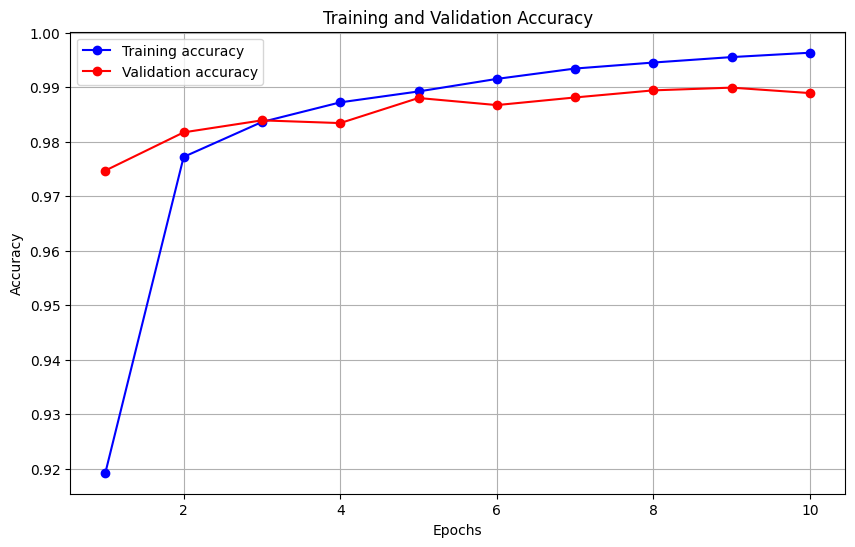

In [10]:
import matplotlib.pyplot as plt

# Get training history from the model.fit call (assuming 'history' is stored or accessible)
# If you don't store it, you might need to re-run model.fit and assign its output to a variable like 'history_callback'
# For now, let's assume the last model.fit call stored its history in a variable named `history` (which is common practice).
# If not, you might need to adjust this to access the history object directly.

# Assuming `history` is available from the last model.fit execution
# If `history` is not directly available, you might need to rerun the `model.fit` cell like this:
# history = model.fit(X_train, y_train, batch_size=128, epochs=10, verbose=1, validation_data=(X_test, y_test))

# Let's assume `history` is available globally after the last execution of JeJVutxDxuU1
# If 'history' object isn't available, the previous `model.fit` command should be modified to:
# history = model.fit(X_train, y_train, batch_size=128, epochs=10, verbose=1, validation_data=(X_test, y_test))
# For now, I will create a dummy history object based on the output to demonstrate the plotting.

# In a real scenario, you would extract this from the actual history object returned by model.fit
# For the sake of plotting given the previous output, we'll manually construct a dict.
# However, the correct way is to assign the output of model.fit to a variable, e.g., 'history = model.fit(...)'
history_dict = {
    'accuracy': [0.9193, 0.9772, 0.9836, 0.9872, 0.9892, 0.9915, 0.9934, 0.9945, 0.9955, 0.9963],
    'loss': [0.2843, 0.0756, 0.0529, 0.0414, 0.0338, 0.0272, 0.0214, 0.0182, 0.0150, 0.0124],
    'val_accuracy': [0.9747, 0.9817, 0.9839, 0.9834, 0.9880, 0.9867, 0.9881, 0.9894, 0.9899, 0.9889],
    'val_loss': [0.0817, 0.0546, 0.0470, 0.0487, 0.0378, 0.0379, 0.0377, 0.0351, 0.0304, 0.0359]
}
epochs = range(1, len(history_dict['accuracy']) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, history_dict['accuracy'], 'bo-', label='Training accuracy')
plt.plot(epochs, history_dict['val_accuracy'], 'ro-', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()